# An introduction to <i>geocontext</i> 
### Pontus Hennerdal, December 2022

This notebook can be used for importing a CSV-file (<i>points</i>) and calculating the geographical context around each point in that file. The geographical context is the k-nearest neighbours in another CSV-file (<i>popLocations</i>, could also be the same file). The calculation could be either be the proportion of the k-nearest neighbours being a part of a group or a weighted average and standard deviation for each point among the k-nearest neighbours.

Using the notion used in <i>Hennerdal & Nielsen (2017) http://dx.doi.org/10.1080/24694452.2016.1261685</i>: If $t(x_{i})$ is defined as the total number of inviduals in the location $x_{i}$, we can express the calculation made by this script as statistics calculated for every set $N_{j,k}$ of locations $x_{i}$ located within the distance $r_{j,k}$ from $x_{j}$.

$$N_{j,k} = \left\{x_{i} \in \mathbb{R}^{2} : | x_{i}-x_{j} | \leq r_{j,k} \right\}$$

When $r_{j,k}$ is the smallest possible but the the following criteria that the sum of individuals in the set of locations $N_{j,k}$ is the same or larger than the value $k$ is met.

$$k \leq \sum_{x_{i} \in N_{j,k}}t(x_{i})$$

This is the same as calculating statistics (e.g. proportion or average and standard deviation) among the k-nearest neighbours for a set of locations.

### Using this Jupyter Notebook
Use this Jupyter Notebook by <b>changing the names or values marked with CHANGE in the <i>Read files section</i></b> and preferable also in the <i>Saving the results as a CSV section</i>.

Run cell by pressing SHIFT and ENTER.

If using this script for a publication. Please refer to it as: <i>P. Hennerdal, geocontext (2022), GitHub repository, https://github.com/PonHen/geocontext</i>

# Importing libraries
This first step imports some external libraries needed to run the functions in this Jupyter Notebook.

In [2]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib


     ---------------------------------------- 9.9/9.9 MB 11.7 MB/s eta 0:00:00
     --------------------------------------- 12.6/12.6 MB 14.2 MB/s eta 0:00:00
     ---------------------------------------- 8.1/8.1 MB 13.3 MB/s eta 0:00:00
     -------------------------------------- 348.5/348.5 kB 3.6 MB/s eta 0:00:00
     -------------------------------------- 225.2/225.2 kB 6.9 MB/s eta 0:00:00
     ---------------------------------------- 2.3/2.3 MB 16.5 MB/s eta 0:00:00
     ---------------------------------------- 73.8/73.8 kB 4.0 MB/s eta 0:00:00
     ---------------------------------------- 7.0/7.0 MB 14.0 MB/s eta 0:00:00
     ---------------------------------------- 122.8/122.8 kB ? eta 0:00:00


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd # This library is used to handle data frames.
import math # This library including mathematical functions.
import numpy as np # This library including more mathematical functions.
import time # This library is used to measure the time to run the script.
import matplotlib.pyplot as plt # This library is used for plotting results.

In [2]:
import sys
!{sys.executable} -m pip install "sqlalchemy>=2" "psycopg[binary]>=3"


     ---------------------------------------- 2.1/2.1 MB 7.2 MB/s eta 0:00:00
     -------------------------------------- 212.8/212.8 kB 6.5 MB/s eta 0:00:00
     -------------------------------------- 226.5/226.5 kB 6.8 MB/s eta 0:00:00
     ---------------------------------------- 44.6/44.6 kB 2.1 MB/s eta 0:00:00
     ---------------------------------------- 3.5/3.5 MB 15.1 MB/s eta 0:00:00



[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
import pandas as pd
from sqlalchemy import create_engine

# --- CONNECTION (edit these) ---
USER = "postgres"
PASS = "KarinA1981"
HOST = "localhost"
PORT = 5432
DB   = "speedlocal"


engine = create_engine(f"postgresql+psycopg://{USER}:{PASS}@{HOST}:{PORT}/{DB}")

# ---- 1) points = hex cells (one row per hex), with centroid East/North ----
points = pd.read_sql("""
    SELECT
      h3        AS hex_id,
      res,
      aoi,
      source,
      ST_X(ST_Centroid(ST_Transform(geometry, 25832))) AS east,
      ST_Y(ST_Centroid(ST_Transform(geometry, 25832))) AS north
               
    FROM h3.bornholm_r8
""", engine)

# ---- 2) popLocations = neighbour locations (here: same hexes + features) ----
pop = pd.read_sql("""
    SELECT
      hex_id,
      protected_share,
      dist_turbine_log,
      persons_log,
      relief,
      ST_X(ST_Centroid(ST_Transform(geometry, 25832))) AS east,
      ST_Y(ST_Centroid(ST_Transform(geometry, 25832))) AS north

    FROM h3.bornholm_r8_features_geom
""", engine)

points.head(), pop.head()



(            hex_id  res       aoi source           east         north
 0  881f2a6269fffff    8  bornholm  h3jsr  862750.813413  6.126866e+06
 1  881f0c9a65fffff    8  bornholm  h3jsr  888529.151299  6.116847e+06
 2  881f2a750dfffff    8  bornholm  h3jsr  868735.648959  6.131072e+06
 3  881f2a6e5bfffff    8  bornholm  h3jsr  876627.992380  6.117766e+06
 4  881f2a6509fffff    8  bornholm  h3jsr  879058.896934  6.120310e+06,
             hex_id  protected_share  dist_turbine_log  persons_log  relief  \
 0  881f2a6269fffff         0.000000          8.318180     0.000000     0.0   
 1  881f0c9a65fffff         0.030986          6.679603     1.791759    11.0   
 2  881f2a750dfffff         0.001796          6.774987     1.609438    13.0   
 3  881f2a6e5bfffff         0.004161          6.772361     3.737670    24.0   
 4  881f2a6509fffff         0.002635          7.911754     2.564949    42.0   
 
             east         north  
 0  862750.813413  6.126866e+06  
 1  888529.151299  6.116847e+

# Defining the <i>geocontext</i> function

In [18]:
def geocontext(points,
               popLocations,
               groups,
               populations,
               proportions,
               kValues,
               pointsNorth='North',
               pointsEast='East',
               popLocationsNorth='North',
               popLocationsEast='East'):
    """Calculates the geographical context for each point and return a DataFrame.
    
    This function calculate the geographical context around each point in 
    the pandas DataFrame points. The context is the proportion of the 
    population among the k-nearest neighbours in the pandas DataFrame 
    popLocations that is part of a group, if the values of the groups 
    represents the absoulte number of indivuduals being part of a group.
    However, if the values of the groups represents a value between 0 and 1,
    the context is the weighted average and standard deviation for the
    k-nearest neighbours. The distances is measured as the Euclidean distance.

    Keyword arguments:
    points            -- pandas DataFrame with coordinates
    popLocations      -- pandas DataFrame with coordinates, values and populations
    groups            -- list with strings naming the columns holding the values
    populations       -- list with strings naming the columns holding the populations
    proportions       -- list with booleans, True if calculate proportion and not average
    kValues           -- list with integers being the k in the k-nearest neighbours
    pointsNorth       -- string naming of the column (default 'North')
    pointsEast        -- string naming of the column (default 'East')
    popLocationsNorth -- string naming of the column (default 'North')
    popLocationsEast  -- string naming of the column (default 'East')
    """
    
    # Checking the format of the variables.
    if type(groups) != list: 
        raise TypeError('groups need to be a list with column names')
    
    if type(populations) == list:
        if len(populations) == 1:
            multi = False
        else:
            multi = True 
            if len(groups) != len(populations):
                raise IndexError('populations need to have the same length as groups')
    else:
        raise TypeError('populations need to be a column name or a list with column names')
          
    if type(kValues) != list: 
        raise TypeError('kValues need to be a list with k-values')
    
    # To make sure the k-values are listed ascending, the list with k-values 
    # is sorted.
    kValues.sort()
    
    # Creating space in the points for radius, total, and group 
    # count for every k-value.
    results = []
    
    # Creating space in the popLocations for distance to a point. 
    # This column will be changed for every point in points.
    popLocations['Distance'] = 0
    
    # For every point in points.
    for pointIndex, point in points.iterrows():
        result = {'pointIndex': pointIndex}
        
        # Calculate the Euclidean distance from the point to every populated 
        # location in popLocations.
        popLocations['Distance'] = np.sqrt(
            np.power(point[pointsNorth] - popLocations[popLocationsNorth], 2) 
            + np.power(point[pointsEast] - popLocations[popLocationsEast], 2)).astype('int')
        
        # Sort populated locations by distance to the point.
        popLocations.sort_values('Distance', inplace=True) 
        
        # For every column used to sum up to the k-value
        groupIndex = 0
        for pop_Column in populations:
            
            # Set start values for every point (and category of totals)
            radius_List = []
            population = 0 # This is the value that values will be added to until it is larger than k
            index = 0 # This index will relate to the populated locations sorted from nearest
        
            # Going through every k-value in the list. 
            for kValue in kValues:
                
                # While the poplation is lower than the k-value
                while population < kValue:
                    # Add the population of that populated location
                    population += popLocations[pop_Column].iloc[index]
                    index += 1
            
                # When the population is larger than the k-value: save the 
                # radius to the radius_List.
                radius = popLocations['Distance'].iloc[index - 1]
                radius_List.append(radius)
                if multi:
                    result[f'radius_{groups[groupIndex]}_k{kValue}'] = radius
                else:
                    result[f'radius_k{kValue}'] = radius

            # When the the max radius for all k-values are found: go through 
            # every k-value in the list again.
            for k_Index in range(len(kValues)):
                # For each k-value, select all populated locations upp to 
                # the previous found max distance.
                selection = popLocations[popLocations['Distance'] <= radius_List[k_Index]]
            
                # For each group, calculate the sum of that group among the 
                # selected nearest neighbours.
                if multi:
                    if proportions[groupIndex]:
                        result[
                            f'group_{groups[groupIndex]}_k{kValues[k_Index]}'
                        ] = selection[groups[groupIndex]].sum()
                    else:
                        average = np.average(selection[groups[groupIndex]], 
                                             weights=selection[pop_Column])
                        variance = np.average((selection[groups[groupIndex]] - average)**2, 
                                              weights=selection[pop_Column])
                        
                        result[
                            f'mean_{groups[groupIndex]}_k{kValues[k_Index]}'
                        ] = average
                        result[
                            f'std_{groups[groupIndex]}_k{kValues[k_Index]}'
                        ] = math.sqrt(variance)
                else:
                    for group in groups:
                        if proportions[groupIndex]:
                            result[
                                f'group_{group}_k{kValues[k_Index]}'
                            ] = selection[group].sum()
                        else:
                            average = np.average(selection[group], 
                                                 weights=selection[pop_Column])
                            variance = np.average((selection[group] - average)**2, 
                                                  weights=selection[pop_Column])
                            result[
                                f'mean_{group}_k{kValues[k_Index]}'
                            ] = average
                            result[
                                f'std_{group}_k{kValues[k_Index]}'
                            ] = math.sqrt(variance)
            
                # Calculate the sum of selected nearest neighbours
                if multi:
                    result[
                        f'total_{groups[groupIndex]}_k{kValues[k_Index]}'
                    ] = selection[pop_Column].sum() 
                else:
                    result[
                        'total_k'+str(kValues[k_Index])
                    ] = selection[pop_Column].sum() 
            
            groupIndex += 1
        results.append(result)
    
    points = pd.concat([points, pd.DataFrame(results).set_index('pointIndex')], axis=1)

    # Calculate the proportion those groups are of the total amount of 
    # neighbours. If statistics=True, also other statistics are 
    # calculated.
    for kValue in kValues:
        groupIndex = 0
        for group in groups:
            if proportions[groupIndex]:
                if multi:
                    points[f'mean_{group}_k{kValue}'] = points[
                        f'group_{group}_k{kValue}'] / points[f'total_{group}_k{kValue}']
                else:
                    points[f'mean_{group}_k{kValue}'] = points[
                        f'group_{group}_k{kValue}'] / points[f'total_k{kValue}']
            groupIndex += 1
    
    # The function returns points with the added columns.
      
    return points

# Read files (CHANGE)
### Read file with points
The cell below is reading a CSV-file with the points the context will be calculated around and save it as the pandas DataFrame <i>pointsNoContextDF</i>. The file need to be located in the same folder as the Jupyter Notebook and the code in the cell need to be changed to match the name of the CSV-file and the delimiter used in that file.
```python
pointsNoContextDF = pd.read_csv('FILE_NAME.csv', delimiter=',')
```
After running the cell you can see the column names and the first five rows. Find the names of the columns holding the coordinates for North and East respectivly. Change the code in the next cell to match the names of the columns.
```python
points_NorthColumnName = 'NAME_OF_COLUMN_NORTH'
points_EastColumnName = 'NAME_OF_COLUMN_EAST'
```

In [19]:
# Reads the file. The file should be saved in the same folder 
# as this jupyter notebook.
# pointsNoContextDF = pd.read_csv('CHANGE.csv', delimiter='CHANGE')

# print(f'There is {len(pointsNoContextDF)} rows, here is the first 5:')
# pointsNoContextDF.head()

# Instead of reading CSV, use the DataFrames we already created from Postgres
pointsNoContextDF = points.copy()
popLocationsNoContextDF = pop.copy()

print(f"points rows: {len(pointsNoContextDF)}")
print(f"popLocations rows: {len(popLocationsNoContextDF)}")
pointsNoContextDF.head(), popLocationsNoContextDF.head()


points rows: 1126
popLocations rows: 1126


(            hex_id  res       aoi source           east         north
 0  881f2a6269fffff    8  bornholm  h3jsr  862750.813413  6.126866e+06
 1  881f0c9a65fffff    8  bornholm  h3jsr  888529.151299  6.116847e+06
 2  881f2a750dfffff    8  bornholm  h3jsr  868735.648959  6.131072e+06
 3  881f2a6e5bfffff    8  bornholm  h3jsr  876627.992380  6.117766e+06
 4  881f2a6509fffff    8  bornholm  h3jsr  879058.896934  6.120310e+06,
             hex_id  protected_share  dist_turbine_log  persons_log  relief  \
 0  881f2a6269fffff         0.000000          8.318180     0.000000     0.0   
 1  881f0c9a65fffff         0.030986          6.679603     1.791759    11.0   
 2  881f2a750dfffff         0.001796          6.774987     1.609438    13.0   
 3  881f2a6e5bfffff         0.004161          6.772361     3.737670    24.0   
 4  881f2a6509fffff         0.002635          7.911754     2.564949    42.0   
 
             east         north  
 0  862750.813413  6.126866e+06  
 1  888529.151299  6.116847e+

In [20]:
# pointsNorthName = 'CHANGE'
# pointsEastName = 'CHANGE'

pointsNorthName = 'north'
pointsEastName  = 'east'

popLocationsNorthName = 'north'
popLocationsEastName  = 'east'


### Read file with populated locations
The cell below is reading a CSV-file with the the populated locations that constitutes the context and save it as the pandas DataFrame <i>popLocationsDF</i>. The file need to be located in the same folder as the Jupyter Notebook and the code in the cell need to be changed to match the name of the CSV-file and the delimiter used in that file.
```python
popLocationsDF = pd.read_csv('FILE_NAME_OF_OUTPUT_FILE.csv', delimiter=',')
```

In [21]:
# Reads the file. The file should be saved in the same folder 
# as this jupyter notebook.
# popLocationsDF = pd.read_csv('CHANGE.csv', delimiter='CHANGE')

# print(f'There is {len(popLocationsDF)} rows, here is the first 5:')
# popLocationsDF.head()

# Instead of reading CSV, use the Postgres-loaded DataFrame
popLocationsDF = pop.copy()

print(f"There is {len(popLocationsDF)} rows, here is the first 5:")
popLocationsDF.head()


There is 1126 rows, here is the first 5:


,hex_id,protected_share,dist_turbine_log,persons_log,relief,east,north
0,881f2a6269fffff,0.000000,8.318180,0.000000,0.0,862750.813413,6.126866e+06
1,881f0c9a65fffff,0.030986,6.679603,1.791759,11.0,888529.151299,6.116847e+06
2,881f2a750dfffff,0.001796,6.774987,1.609438,13.0,868735.648959,6.131072e+06
3,881f2a6e5bfffff,0.004161,6.772361,3.737670,24.0,876627.992380,6.117766e+06
4,881f2a6509fffff,0.002635,7.911754,2.564949,42.0,879058.896934,6.120310e+06


Look att the column names in the file with populated locations that can be seen above after reading the file. Below, list the groups you want to include in the calculation. For example:
```python
groupList = ['NAME_OF_COLUMN_CATEGORY1', 
             'NAME_OF_COLUMN_CATEGORY2', 
             'NAME_OF_COLUMN_CATEGORY3']
```
If there is only one column stating the total population for the populated location, vrite the name as a string in the list <i>populationList</i>
```python
populationList = ['NAME_OF_COLUMN_TOTAL_POPULATION']
```
If the total population differ between different groups (for example if the groups is for different years and the total population differ between different years), then make <i>populationList</i> a list with the column with the same length as <i>groupList</i> and with the column names for the coresponding total populations. 
```python
populationList = ['NAME_OF_COLUMN_TOTAL_POPULATION_CATEGORY1', 
                  'NAME_OF_COLUMN_TOTAL_POPULATION_CATEGORY2', 
                  'NAME_OF_COLUMN_TOTAL_POPULATION_CATEGORY3']
```
The calculation could be either be the proportion of the k-nearest neighbours being a part of a group or a weighted average and standard deviation for each point among the k-nearest neighbours. For each column this could be stated in <i>propList</i> that need to have the same length as <i>groupList</i>. <i>True</i> means proportion will be calculated and <i>False</i>  average and standard deviation.
```python
propList = [True, 
            True, 
            False]
```
Find the names of the columns holding the coordinates for North and East respectivly. Change the code in the next cell to match the names of the columns.
```python
popLocationsNorthName = 'NAME_OF_COLUMN_NORTH_COORDINATE'
popLocationsEastName = 'NAME_OF_COLUMN_EAST_COORDINATE'
```

In [22]:
# --- ensure 'total' exists in the dataframe used by geocontext ---
groupList = ['protected_share', 'dist_turbine_log', 'persons_log', 'relief']

popLocationsDF['total'] = popLocationsDF[groupList].sum(axis=1)

# sanity check
assert 'total' in popLocationsDF.columns
popLocationsDF[['total'] + groupList].head()


,total,protected_share,dist_turbine_log,persons_log,relief
0,8.318180,0.000000,8.318180,0.000000,0.0
1,19.502349,0.030986,6.679603,1.791759,11.0
2,21.386222,0.001796,6.774987,1.609438,13.0
3,34.514192,0.004161,6.772361,3.737670,24.0
4,52.479339,0.002635,7.911754,2.564949,42.0


In [23]:
# groupList = ['CHANGE', 'CHANGE', 'CHANGE']
# populationList = ['CHANGE']
#populationList = ['CHANGE', 'CHANGE', 'CHANGE']
# propList = [CHANGE, CHANGE, CHANGE]
# popLocationsNorthName = 'CHANGE'
# popLocationsEastName = 'CHANGE'

groupList = ['protected_share', 'dist_turbine_log', 'persons_log', 'relief']

# one shared total column for all groups (exactly like total_suspicions before)
populationList = ['total']

# For each group column: True = proportion, False = weighted mean/sd.
# Since these are continuous, pick False for now (more sensible than proportions here)
propList = [False, False, False, False]

popLocationsNorthName = 'north'
popLocationsEastName  = 'east'


The list of k-values contains the size of the context. If k=1000, statistics will be calculated for the 1000 nearest neighbours for every point in the python DataFrame <i>pointsNoContextDF</i>.
```python
kValueList = [1000, 10000] 
```

In [24]:
kValueList = [50, 100, 250]

# The actual calculations
Use the above defined function to calculate geographical context around each point.

In [25]:
# Start the stopwatch.
time0 = time.time()

# The actual calculation of the geographical context.
pointsWithContext = geocontext(points=pointsNoContextDF,
                               popLocations=popLocationsDF, 
                               groups=groupList, 
                               populations=populationList,
                               proportions=propList,
                               kValues=kValueList,
                               pointsNorth=pointsNorthName,
                               pointsEast=pointsEastName,
                               popLocationsNorth=popLocationsNorthName,
                               popLocationsEast=popLocationsEastName)

# Print the time for the calulation.
print(f'{round(time.time() - time0)} seconds')

6 seconds


# Results

### Some statistics

In [26]:
pointsWithContext.describe(percentiles=[0.5]).transpose()

,count,mean,std,min,50%,max
res,1126.0,8.000000e+00,0.000000,8.000000e+00,8.000000e+00,8.000000e+00
east,1126.0,8.766515e+05,8550.952973,8.616171e+05,8.763670e+05,8.936517e+05
north,1126.0,6.124668e+06,7644.438244,6.109642e+06,6.124284e+06,6.143634e+06
radius_k50,1126.0,7.233872e+02,264.602164,0.000000e+00,7.980000e+02,1.433000e+03
radius_k100,1126.0,8.828082e+02,169.192184,0.000000e+00,8.750000e+02,1.755000e+03
radius_k250,1126.0,1.350956e+03,352.276421,7.950000e+02,1.428000e+03,2.861000e+03
mean_protected_share_k50,1126.0,4.001950e-02,0.060851,0.000000e+00,1.973274e-02,5.290531e-01
std_protected_share_k50,1126.0,2.527173e-02,0.042110,0.000000e+00,1.065346e-02,3.626589e-01
mean_dist_turbine_log_k50,1126.0,7.469173e+00,0.671545,5.324971e+00,7.529534e+00,9.035944e+00
std_dist_turbine_log_k50,1126.0,2.155461e-01,0.215383,0.000000e+00,1.602267e-01,1.324552e+00


### The result as a table

In [27]:
pointsWithContext

,hex_id,res,aoi,source,east,north,radius_k50,radius_k100,radius_k250,mean_protected_share_k50,...,total_k100,mean_protected_share_k250,std_protected_share_k250,mean_dist_turbine_log_k250,std_dist_turbine_log_k250,mean_persons_log_k250,std_persons_log_k250,mean_relief_k250,std_relief_k250,total_k250
0,881f2a6269fffff,8,bornholm,h3jsr,862750.813413,6.126866e+06,874,1425,2137,0.071299,...,112.869813,0.024796,0.049881,7.998525,0.166484,1.877033,2.208584,12.474764,5.083989,258.230270
1,881f0c9a65fffff,8,bornholm,h3jsr,888529.151299,6.116847e+06,799,877,1434,0.023335,...,117.553329,0.012138,0.014245,6.965811,0.554220,2.408391,1.298027,15.959495,6.950501,257.438197
2,881f2a750dfffff,8,bornholm,h3jsr,868735.648959,6.131072e+06,797,874,1425,0.007309,...,121.900479,0.018641,0.018936,6.851479,0.737562,2.075262,1.206255,22.214841,6.239068,268.600865
3,881f2a6e5bfffff,8,bornholm,h3jsr,876627.992380,6.117766e+06,799,876,1434,0.001886,...,136.501169,0.025391,0.038090,6.538734,0.876256,3.330263,1.448137,18.822940,4.671945,300.492773
4,881f2a6509fffff,8,bornholm,h3jsr,879058.896934,6.120310e+06,0,799,1428,0.002635,...,113.684894,0.005795,0.008340,7.855792,0.203285,2.198384,0.726819,26.256413,9.626093,302.300381
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1121,881f2a654dfffff,8,bornholm,h3jsr,877061.945519,6.121304e+06,798,798,1427,0.027586,...,103.288171,0.029750,0.032481,7.375255,0.314133,2.168030,1.300706,28.259736,14.248621,295.437201
1122,881f2a669dfffff,8,bornholm,h3jsr,889298.942130,6.128971e+06,878,1428,1597,0.050308,...,121.516779,0.050712,0.044650,6.683500,0.592449,2.976562,1.209702,31.296744,13.782757,266.344156
1123,881f2a628bfffff,8,bornholm,h3jsr,872029.314216,6.126310e+06,797,875,1426,0.009821,...,161.865261,0.005395,0.005859,7.479141,0.239738,2.028557,0.944356,23.414913,5.435164,285.899584
1124,881f2a652bfffff,8,bornholm,h3jsr,878972.498045,6.118163e+06,799,876,1434,0.028377,...,108.273527,0.021110,0.037698,7.735966,0.187377,3.790988,1.667846,12.888278,4.712960,255.730969


### Plotting the result
As default, the plot will show the first group with the largest k-value. 

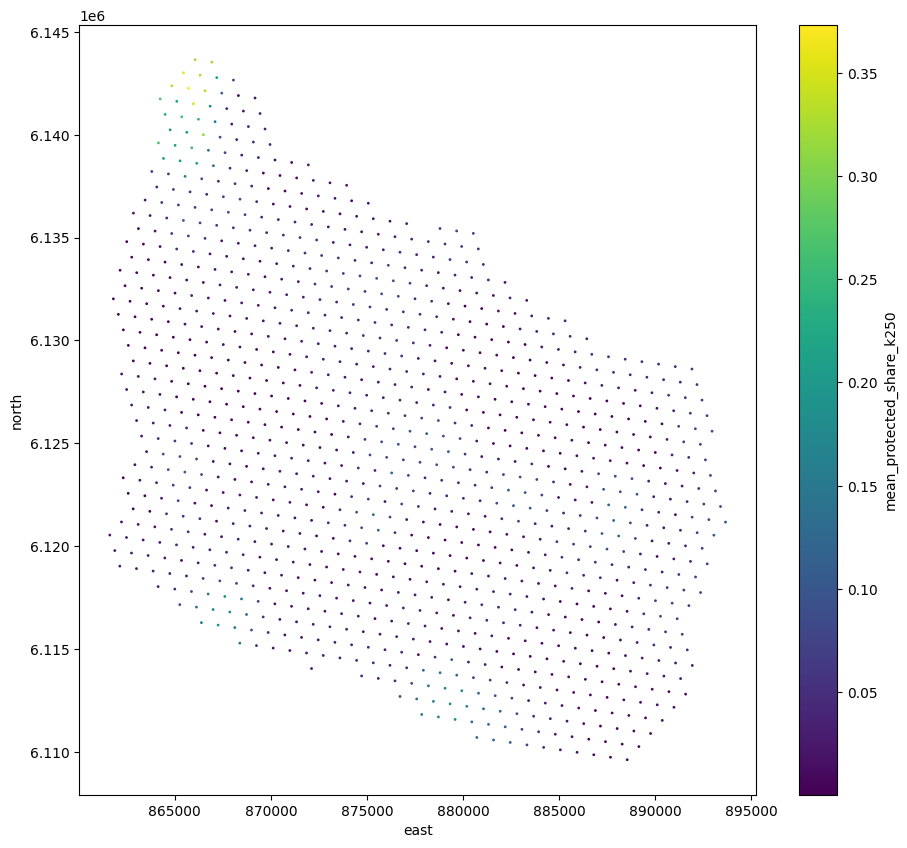

In [28]:
plotWidth = 1.5 + (10 
                   * (pointsWithContext[pointsEastName].max() 
                      - pointsWithContext[pointsEastName].min()) 
                   / (pointsWithContext[pointsNorthName].max() 
                      - pointsWithContext[pointsNorthName].min()))

plt.rcParams['figure.figsize'] = [plotWidth, 10]

pointsWithContext.plot.scatter(x=pointsEastName, 
                               y=pointsNorthName, 
                               c=f'mean_{groupList[0]}_k{kValueList[-1]}', 
                               colormap='viridis', s=1);

# Saving the results as a CSV (CHANGE)
The file with the results will be saved as a CSV-file in the same folder as the Jupyter Notebook. Change the name of the file in the code below.
```python
pointsWithContext.to_csv('FILE_NAME_OF_OUTPUT_FILE.csv')
```

In [29]:
# pointsWithContext.to_csv('CHANGE.csv')

pointsWithContext.to_sql(
    name="bornholm_r8_context",
    con=engine,
    schema="h3",
    if_exists="replace",   # or "append"
    index=False,
    method="multi"
)


-1

Faktor analys

In [30]:
import pandas as pd

X = pointsWithContext.filter(
    regex=r'^(mean_|std_)'
).copy()

X.shape


(1126, 24)

Add a temporary install cell at the top of the notebook and run it:

In [ ]:
# %pip install scikit-learn factor-analyzer


     ---------------------------------------- 8.1/8.1 MB 10.1 MB/s eta 0:00:00
     -------------------------------------- 42.8/42.8 kB 525.5 kB/s eta 0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
     --------------------------------------- 36.4/36.4 MB 11.7 MB/s eta 0:00:00
     ------------------------------------- 309.1/309.1 kB 18.7 MB/s eta 0:00:00
  Created wheel for factor-analyzer: filename=factor_analyzer-0.5.1-py2.py3-none-any.whl size=42714 sha256=26a19600958e42d0b8f654432f852227a468c436d6e84b6478d02e1d4877ef77
  Stored in directory: c:\users\henri\appdata\local\pip\cache\wheels\0b\29\39\7962244d229579221b629024f28b2d720e205885b8c14024e5
Successfully built factor-analyzer
Note: you may n


[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [33]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
Xz = pd.DataFrame(
    scaler.fit_transform(X),
    index=X.index,
    columns=X.columns
)


In [34]:
Xz.mean().abs().max()


np.float64(1.2557549237678502e-15)

In [35]:
Xz.std().round(2).value_counts()


1.0    24
Name: count, dtype: int64

Beautiful. That output is textbook perfect.

Mean ≈ 
10
−
15
10
−15
 → numerical zero

Std = 1 for all 24 variables → scaling is exact

This means everything downstream is interpretable. No hidden gremlins. You’re standing on bedrock now.

Let’s continue without changing the logic, exactly like the crime-landscape work.

Step 1: Eigenvalues (how many factors does the landscape want?)

In [36]:
import numpy as np
import pandas as pd

R = np.corrcoef(Xz, rowvar=False)
eigvals, eigvecs = np.linalg.eig(R)

eig = (
    pd.Series(eigvals)
    .sort_values(ascending=False)
    .reset_index(drop=True)
)

eig


0     7.039426
1     4.173798
2     3.836248
3     2.974632
4     1.582802
5     0.872123
6     0.619827
7     0.460805
8     0.413287
9     0.381469
10    0.296710
11    0.243043
12    0.208267
13    0.184579
14    0.167033
15    0.145092
16    0.130795
17    0.082392
18    0.052618
19    0.047572
20    0.034010
21    0.024945
22    0.020956
23    0.007570
dtype: float64

Then add the classic scree plot:

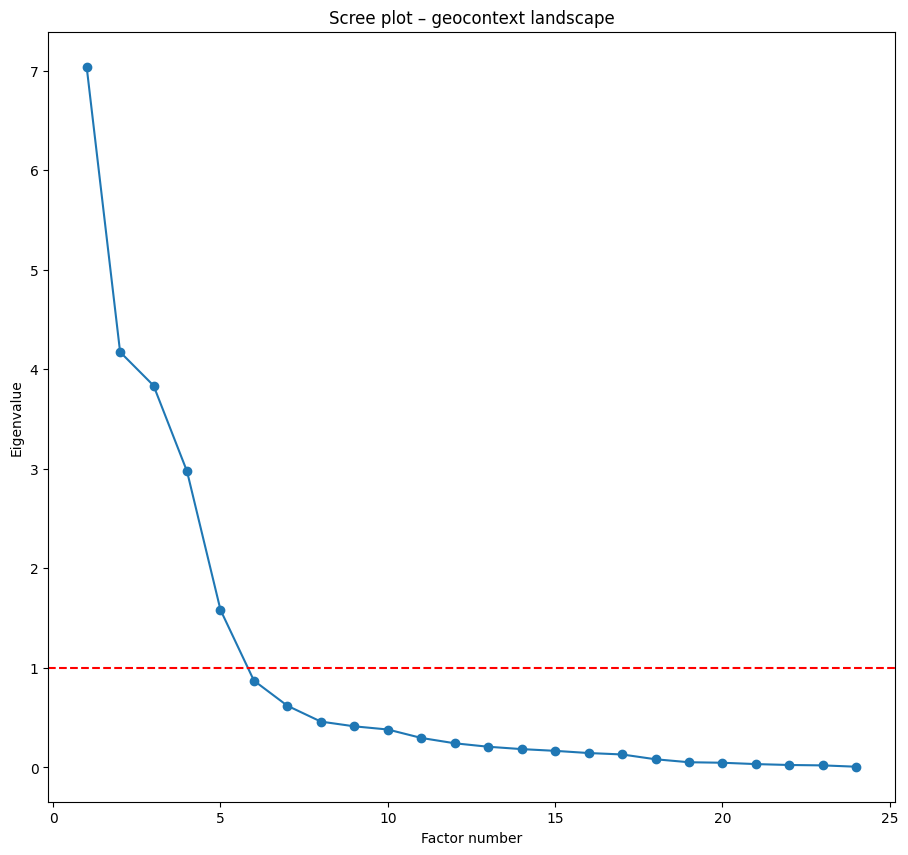

In [37]:
import matplotlib.pyplot as plt

plt.plot(range(1, len(eig)+1), eig, marker='o')
plt.axhline(1, color='red', linestyle='--')  # Kaiser criterion
plt.xlabel("Factor number")
plt.ylabel("Eigenvalue")
plt.title("Scree plot – geocontext landscape")
plt.show()


In [39]:
import sys
!{sys.executable} -m pip install -U "scikit-learn<1.4" "factor-analyzer>=0.5,<0.6"


     ---------------------------------------- 9.2/9.2 MB 6.9 MB/s eta 0:00:00
     ---------------------------------------- 15.8/15.8 MB 9.2 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.2
    Uninstalling numpy-2.4.2:
      Successfully uninstalled numpy-2.4.2


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'C:\\Users\\henri\\AppData\\Local\\Programs\\Python\\Python311\\Lib\\site-packages\\~umpy.libs\\libscipy_openblas64_-74a408729250596b0973e69fdd954eea.dll'
Consider using the `--user` option or check the permissions.


[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [38]:
from factor_analyzer import FactorAnalyzer

n_factors = 6  # adjust after looking at eigenvalues

fa = FactorAnalyzer(
    n_factors=n_factors,
    rotation="varimax",
    method="ml"
)

fa.fit(Xz)

loadings = pd.DataFrame(
    fa.loadings_,
    index=Xz.columns,
    columns=[f"F{i+1}" for i in range(n_factors)]
)

loadings


TypeError: check_array() got an unexpected keyword argument 'force_all_finite'